In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.current_device())
gpu = torch.device('cuda:0')

True
0


In [65]:
torch.cuda.empty_cache()

In [2]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(555)

In [15]:
IMG_PATH = "../../dataset/one_revoc/img/"
LABEL_PATH = "../../dataset/one_revoc/label.csv" # (xmin, ymin, xmax, ymax)
ALT_LABEL_PATH = "../../dataset/one_revoc/alt_label.csv" # (x_center, y_center, width, height)
OBJ_PATH = "../../dataset/obj_norm/"

In [36]:
import torchvision
import torch.nn
from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Pad
from torchvision.io import decode_image
from torchinfo import summary as model_summary

In [26]:
# Subset of VOC'2012 with object removed that CONTAIN ONLY 1 IMAGE
# We stack the tensors for the image and obj together
class CustomDataset(Dataset):
    def __init__(self, label_dir, img_dir, obj_dir, transform=None, target_transform=None, label_names=("img_name","xmin","ymin","xmax","ymax")):
        self.bbox_label = pd.read_csv(label_dir, names=label_names)
        self.img_dir = img_dir
        self.obj_dir = obj_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.bbox_label)

    def __getitem__(self, idx):    
        img_name = self.bbox_label.iloc[idx, 0]
        obj_name = img_name[:-3] + "png"
        img_path = os.path.join(self.img_dir, img_name)
        obj_path = os.path.join(self.obj_dir, obj_name)       
        image = decode_image(img_path).type(torch.float32)
        obj = decode_image(obj_path).type(torch.float32)
        label = torch.tensor([self.bbox_label.iloc[idx, i] for i in range(1,5)]).type(torch.float32)
        if self.transform:
            image = pad_to_500(self.transform(image))
            obj = self.transform(obj)
        if self.target_transform:
            label = self.target_transform(label)
        example = torch.cat((image,obj),0)
        
        return example.to(gpu), label.to(gpu)

    def get_imgname(self, idx):
        return self.bbox_label.iloc[idx, 0]

In [11]:
def get_imgname(revoc, img):
    for idx in range(len(revoc)):
        ds_img, _ = revoc[idx]
        if torch.equal(img, ds_img):
            return revoc.get_imgname(idx)

In [18]:
def pad_to_500(img):
    down = 500 - img.shape[1]
    right = 500 - img.shape[2]
    pad = Pad((0,0,right,down))
    return pad(img)

In [12]:
resnet_preprocess = torchvision.transforms.Compose([
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [41]:
batch_size = 32

revoc = CustomDataset(label_dir=LABEL_PATH,
                      img_dir=IMG_PATH,
                      obj_dir=OBJ_PATH,
                      transform=resnet_preprocess)
train_dataset, test_dataset = torch.utils.data.random_split(revoc, [0.8, 0.2])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [42]:
model = torch.hub.load('pytorch/vision', 'resnet50', weights="IMAGENET1K_V2")

Using cache found in /home/jay/.cache/torch/hub/pytorch_vision_main


In [43]:
model.fc = torch.nn.Linear(2048, 4)

In [44]:
old_weights = model.conv1.weight.data

In [45]:
new_input_layer = torch.nn.Conv2d(6, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False)

In [46]:
new_input_layer.weight.data[:, :3, :, :] = old_weights
new_input_layer.weight.data[:, 3:, :, :] = old_weights

In [51]:
model.conv1 = new_input_layer

In [52]:
model.to(gpu)

ResNet(
  (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [53]:
def train_loop(dataloader, model, loss_fn, optimizer, t=None):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    if t is not None:
        training_result[t] = {"train": total_loss/len(dataloader)}

In [54]:
def test_loop(dataloader, model, loss_fn, t=None):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    
    print(f"Test Loss: {test_loss}")
    if t is not None:
        training_result[t]["test"] = test_loss

In [55]:
learning_rate = 0.001

training_result = {}

loss_fn = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer,t)
    test_loop(test_dataloader, model, loss_fn,t)
print("Done!")

Epoch 1
-------------------------------
loss: 9397873.000000  [   32/ 1107]
Test Loss: 4441840.527777778
Epoch 2
-------------------------------
loss: 4810346.000000  [   32/ 1107]
Test Loss: 1734329.5
Epoch 3
-------------------------------
loss: 2201675.500000  [   32/ 1107]
Test Loss: 1680491.9305555555
Epoch 4
-------------------------------
loss: 1247211.125000  [   32/ 1107]
Test Loss: 964201.6736111111
Epoch 5
-------------------------------
loss: 876215.687500  [   32/ 1107]
Test Loss: 1415563.5347222222
Epoch 6
-------------------------------
loss: 935811.250000  [   32/ 1107]
Test Loss: 1135949.7222222222
Epoch 7
-------------------------------
loss: 891114.625000  [   32/ 1107]
Test Loss: 827712.9097222222
Epoch 8
-------------------------------
loss: 816957.437500  [   32/ 1107]
Test Loss: 1986591.9166666667
Epoch 9
-------------------------------
loss: 903166.875000  [   32/ 1107]
Test Loss: 866532.5625
Epoch 10
-------------------------------
loss: 800657.750000  [   32/ 

In [40]:
training_result

{0: {'train': 7058789.478571429, 'test': 5042725.611111111},
 1: {'train': 3266240.567857143, 'test': 2172785.777777778},
 2: {'train': 1580611.4982142858, 'test': 1110076.5208333333},
 3: {'train': 1016038.9910714285, 'test': 921262.1666666666},
 4: {'train': 893142.7964285715, 'test': 1757208.4583333333},
 5: {'train': 872724.5375, 'test': 1054217.7708333333},
 6: {'train': 865217.3785714286, 'test': 2518965.5},
 7: {'train': 856593.1517857143, 'test': 863652.9236111111},
 8: {'train': 842095.1553571429, 'test': 1587726.0972222222},
 9: {'train': 812122.9383928571, 'test': 984368.4097222222},
 10: {'train': 805470.1892857143, 'test': 2573010.5416666665},
 11: {'train': 775884.7625, 'test': 967386.1597222222},
 12: {'train': 731761.4580357143, 'test': 907176.375},
 13: {'train': 704617.1160714285, 'test': 914595.7986111111},
 14: {'train': 684746.7946428572, 'test': 1138904.8194444445},
 15: {'train': 668516.6526785714, 'test': 894396.7847222222},
 16: {'train': 655054.7732142857, 'te

In [56]:
x = list(training_result.keys())

In [57]:
y,y2 = [], []
for i in range(100):
    y.append(training_result[i]["train"])
    y2.append(training_result[i]["test"])

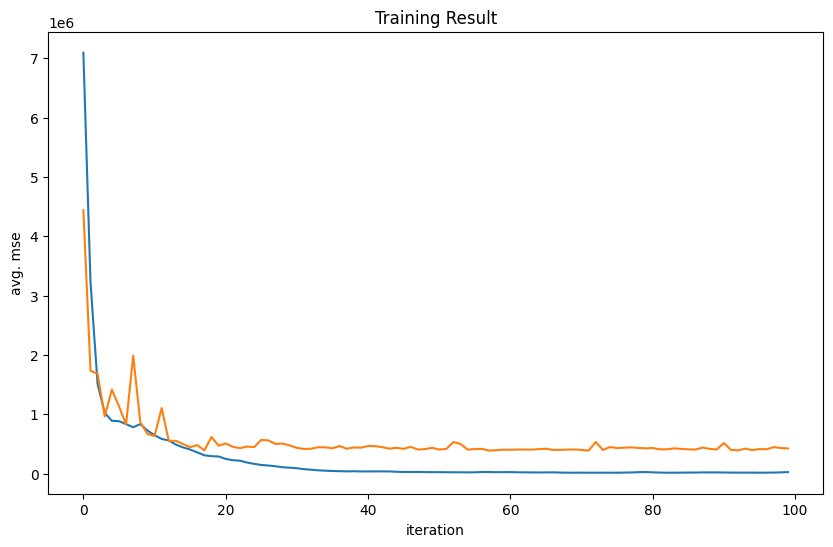

In [58]:
fig= plt.figure(figsize=(10,6))
plt.title("Training Result")
plt.xlabel("iteration")
plt.ylabel("avg. mse")
plt.plot(x,y)
plt.plot(x,y2)
plt.show()

In [59]:
torch.save(model.state_dict(), "weights.pt")

In [60]:
import json
with open("trainingresult.json", "w") as f:
    json.dump(training_result, f)

In [61]:
def save_eval(dataset, model, loss_fn, out_dir="output/"):
    # Do prediction one by one so we can save result
    model.eval()
    total_loss = 0

    with open(os.path.join(out_dir, "output.csv"), "a") as out_file:
    
        # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
        # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
        with torch.no_grad():
            for X, y in dataset:
                pred = model(X)
                out_name = []
                out_label = []
                out_pred = []
                for x in X:
                    name = get_imgname(revoc, x)
                    # name = "placeholder"
                    out_name.append(name)
                for label in y:
                    xmin, ymin, xmax, ymax = [str(int(x)) for x in label.tolist()]
                    out_label.append(",".join([xmin, ymin, xmax, ymax]))
                for label in pred:
                    pred_xmin, pred_ymin, pred_xmax, pred_ymax = [str(int(x)) for x in label.tolist()]
                    out_pred.append(",".join([pred_xmin, pred_ymin, pred_xmax, pred_ymax]))
                for i in range(len(out_name)):
                    out_file.write(out_name[i] + "," + out_label[i] + "," + out_pred[i] + "\n")
        
        

In [62]:
save_eval(test_dataloader, model, loss_fn)

In [63]:
with open("output/output.csv","r") as f:
    print(len(f.readlines()))

276


In [64]:
len(test_dataset)

276

In [117]:
test_loop(test_dataloader, model, loss_fn)

15726624.0


In [28]:
torchvision.models.get_model_weights('resnet50')

<enum 'ResNet50_Weights'>

In [20]:
test_img, _ = revoc[1]

In [15]:
test_img.shape

torch.Size([3, 309, 500])

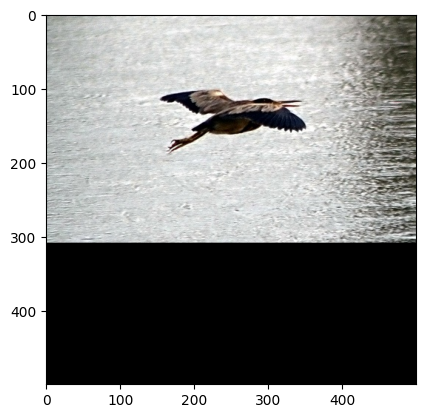

In [21]:
plt.imshow(test_img.permute(1, 2, 0))
plt.show()

In [31]:
test_csv = pd.read_csv(BBOX_PATH)

In [32]:
test_csv.iloc[

,img_name,xmin,ymin,xmax,ymax
0,2009_002117.jpg,48,85,426,242
1,2007_001289.jpg,157,98,355,188
2,2008_001610.jpg,125,124,280,297
3,2008_005541.jpg,35,91,500,256
4,2011_002559.jpg,32,1,373,375
...,...,...,...,...,...
1384,2009_002734.jpg,81,59,397,305
1385,2009_000892.jpg,233,77,392,271
1386,2010_002556.jpg,40,205,463,288
1387,2010_003473.jpg,125,28,345,324


In [35]:
test_csv.iloc[0, 2]

np.int64(85)

In [22]:
img_list

['2009_002117.txt',
 '2007_001289.txt',
 '2008_001610.txt',
 '2008_005541.txt',
 '2011_002559.txt',
 '2009_002638.txt',
 '2009_000100.txt',
 '2009_000731.txt',
 '2007_007772.txt',
 '2011_001967.txt',
 '2007_005696.txt',
 '2007_002896.txt',
 '2009_003461.txt',
 '2010_003737.txt',
 '2010_005952.txt',
 '2007_007387.txt',
 '2008_005845.txt',
 '2008_003252.txt',
 '2010_004520.txt',
 '2009_001664.txt',
 '2010_004382.txt',
 '2008_005770.txt',
 '2007_009422.txt',
 '2011_001775.txt',
 '2011_001281.txt',
 '2009_002604.txt',
 '2009_000242.txt',
 '2011_001722.txt',
 '2008_000105.txt',
 '2008_001215.txt',
 '2009_002448.txt',
 '2010_002750.txt',
 '2010_005932.txt',
 '2010_005016.txt',
 '2007_002094.txt',
 '2008_000422.txt',
 '2009_004255.txt',
 '2010_004856.txt',
 '2011_001866.txt',
 '2008_003415.txt',
 '2007_005210.txt',
 '2010_002778.txt',
 '2010_000437.txt',
 '2011_000513.txt',
 '2010_005978.txt',
 '2008_004701.txt',
 '2007_001834.txt',
 '2008_002258.txt',
 '2009_000351.txt',
 '2008_004822.txt',


In [28]:
with open ("one_revoc/new_label.csv", "w") as label:
    label.write("img_name,xmin,ymin,xmax,ymax\n")
    for fn in img_list:
        with open("one_revoc/bbox/" + fn, "r") as bbox:
            bbox_data = bbox.read()
        img_name = fn.split(".")[0] + ".jpg"
        label.write(img_name + "," + bbox_data+"\n")

In [30]:
!cat one_revoc/new_label.csv

img_name,xmin,ymin,xmax,ymax
2009_002117.jpg,48,85,426,242
2007_001289.jpg,157,98,355,188
2008_001610.jpg,125,124,280,297
2008_005541.jpg,35,91,500,256
2011_002559.jpg,32,1,373,375
2009_002638.jpg,40,76,494,321
2009_000100.jpg,100,86,277,449
2009_000731.jpg,52,1,500,333
2007_007772.jpg,149,87,321,270
2011_001967.jpg,23,22,366,423
2007_005696.jpg,4,101,325,436
2007_002896.jpg,124,71,253,500
2009_003461.jpg,19,62,447,304
2010_003737.jpg,68,135,487,251
2010_005952.jpg,70,1,256,474
2007_007387.jpg,19,25,484,245
2008_005845.jpg,142,13,363,305
2008_003252.jpg,136,77,436,373
2010_004520.jpg,81,23,246,481
2009_001664.jpg,129,1,455,301
2010_004382.jpg,65,8,410,360
2008_005770.jpg,54,42,500,375
2007_009422.jpg,2,2,481,325
2011_001775.jpg,1,1,499,375
2011_001281.jpg,187,144,500,346
2009_002604.jpg,179,177,277,275
2009_000242.jpg,54,218,476,375
2011_001722.jpg,24,31,267,206
2008_000105.jpg,215,182,377,240
2008_001215.jpg,72,89,381,307
2009_002448.jpg,18,101,333,383
2010_002750.jpg,155,182,181,208


In [29]:
!ls one_revoc

bbox  img  label.csv  new_label.csv  obj  readme.txt


In [5]:
import os
img_list = os.listdir(BBOX_PATH)